In [1]:
# Data Profiling

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

print("The environment is ready: pandas", pd.__version__)


The environment is ready: pandas 3.0.3


In [2]:
df = pd.read_csv("data/yaleemmlc_admissionprediction_triage.csv")
print(f"Loaded {df.shape[0]:,} ED encounters x {df.shape[1]} columns")
df.head()

# Convert temperature from Fahrenheit to Celsius: C = (F - 32) * 5/9
df["triage_vital_temp_c"] = (df["triage_vital_temp"] - 32) * 5 / 9

Loaded 55,121 ED encounters x 226 columns


/var/folders/j9/hxxpzry91651vtmqmbk4443m0000gn/T/ipykernel_47770/4271389098.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["triage_vital_temp_c"] = (df["triage_vital_temp"] - 32) * 5 / 9


In [3]:
# SCHEMA MAP 
# Schema map - a set of rules that define how data fields and tables in one system correspond to elements from another system.

TARGET = "esi" # ESI - Emeergency Severity Index

# Vital signs that are measured during triage 
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]

# Information regarding the patitent 
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion", 
                "maritalstatus", "employstatus", "insurance_status"]

# Administrative details 
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]

# Outcomes of the visit. This information is known AFTER triage and therfore not included in the model
LEAKAGE = ["disposition", "previousdispo"]

def classify_columns(df):
    """Sort the DataFrame columns into families and return them in a dictionary"""
    def keep_present(wanted):         # wanted = list of column names to check
        present = []                  # hold any columns that exist 
        for col in wanted:            # go through each requested colum
            if col in df.columns:     # check if it is in the dataset
                present.append(col)   # present? keep
        return present
    
    chief_complaints = []                   # hold all chief-complaint column names
    for col in df.columns:                  # go through every column of the dataset
        if col.startswith("cc_"):           # checks if it is a chief-complaint flag   
            chief_complaints.append(col)    # if present, adds to list

    families = {
        "target":           keep_present([TARGET]),
        "vitals":           keep_present(VITALS),
        "demographics":     keep_present(DEMOGRAPHICS),
        "admin":            keep_present(ADMIN),
        "leakage":          keep_present(LEAKAGE),
        "chief_complaints": chief_complaints,
    }
    return families    

In [4]:
# Reference ranges for an adult triage. 
# Celsius version for temperature is included. 

NORMAL_RANGES = {"triage_vital_hr": (60,100,"bpm"), "triage_vital_sbp": (90,140,"mmHg"),
    "triage_vital_dbp": (60,90,"mmHg"), "triage_vital_rr": (12,20,"/min"),
    "triage_vital_o2": (95,100,"%"), "triage_vital_temp": (97.0,99.5,"F"), 
    "triage_vital_temp_c":(30,43.3), "triage_glucose": (70,140,"mg/dL")}

PLAUSIBLE ={"age": (0,120), "esi": (1,5), "triage_vital_hr": (20,250), "triage_vital_sbp": (50,300),
    "triage_vital_dbp": (20,200), "triage_vital_rr": (4,60), "triage_vital_o2": (50,100),
    "triage_vital_temp": (86,110), "triage_vital_temp_c": (30,43.3), "triage_glucose": (20,800)}



In [5]:
fam = classify_columns(df)
structured = [col for col in df.columns if not col.startswith("cc_")]
# the list "structured" means all the columns except the chief complaint.

In [6]:
# Missing data check

# step 1: counting how many values are missing from each column.
# Divide by the total number of rows to get the missing fraction
missing_fraction = df[structured].isna().sum() / len(df)

# step 2: converting to a percentage 
missing_percent = (missing_fraction * 100).round(1)

# step 3: ensure the most incomplete columns show up first
missing_percent = missing_percent.sort_values(ascending=False)

# Step 4: keep the columns that only have missing data
cols_with_gaps = missing_percent[missing_percent > 0]

# quick summary
print(f"{len(cols_with_gaps)} out of {len(structured)} structured columns have missing data:\n")
cols_with_gaps

0 out of 27 structured columns have missing data:



Series([], dtype: float64)

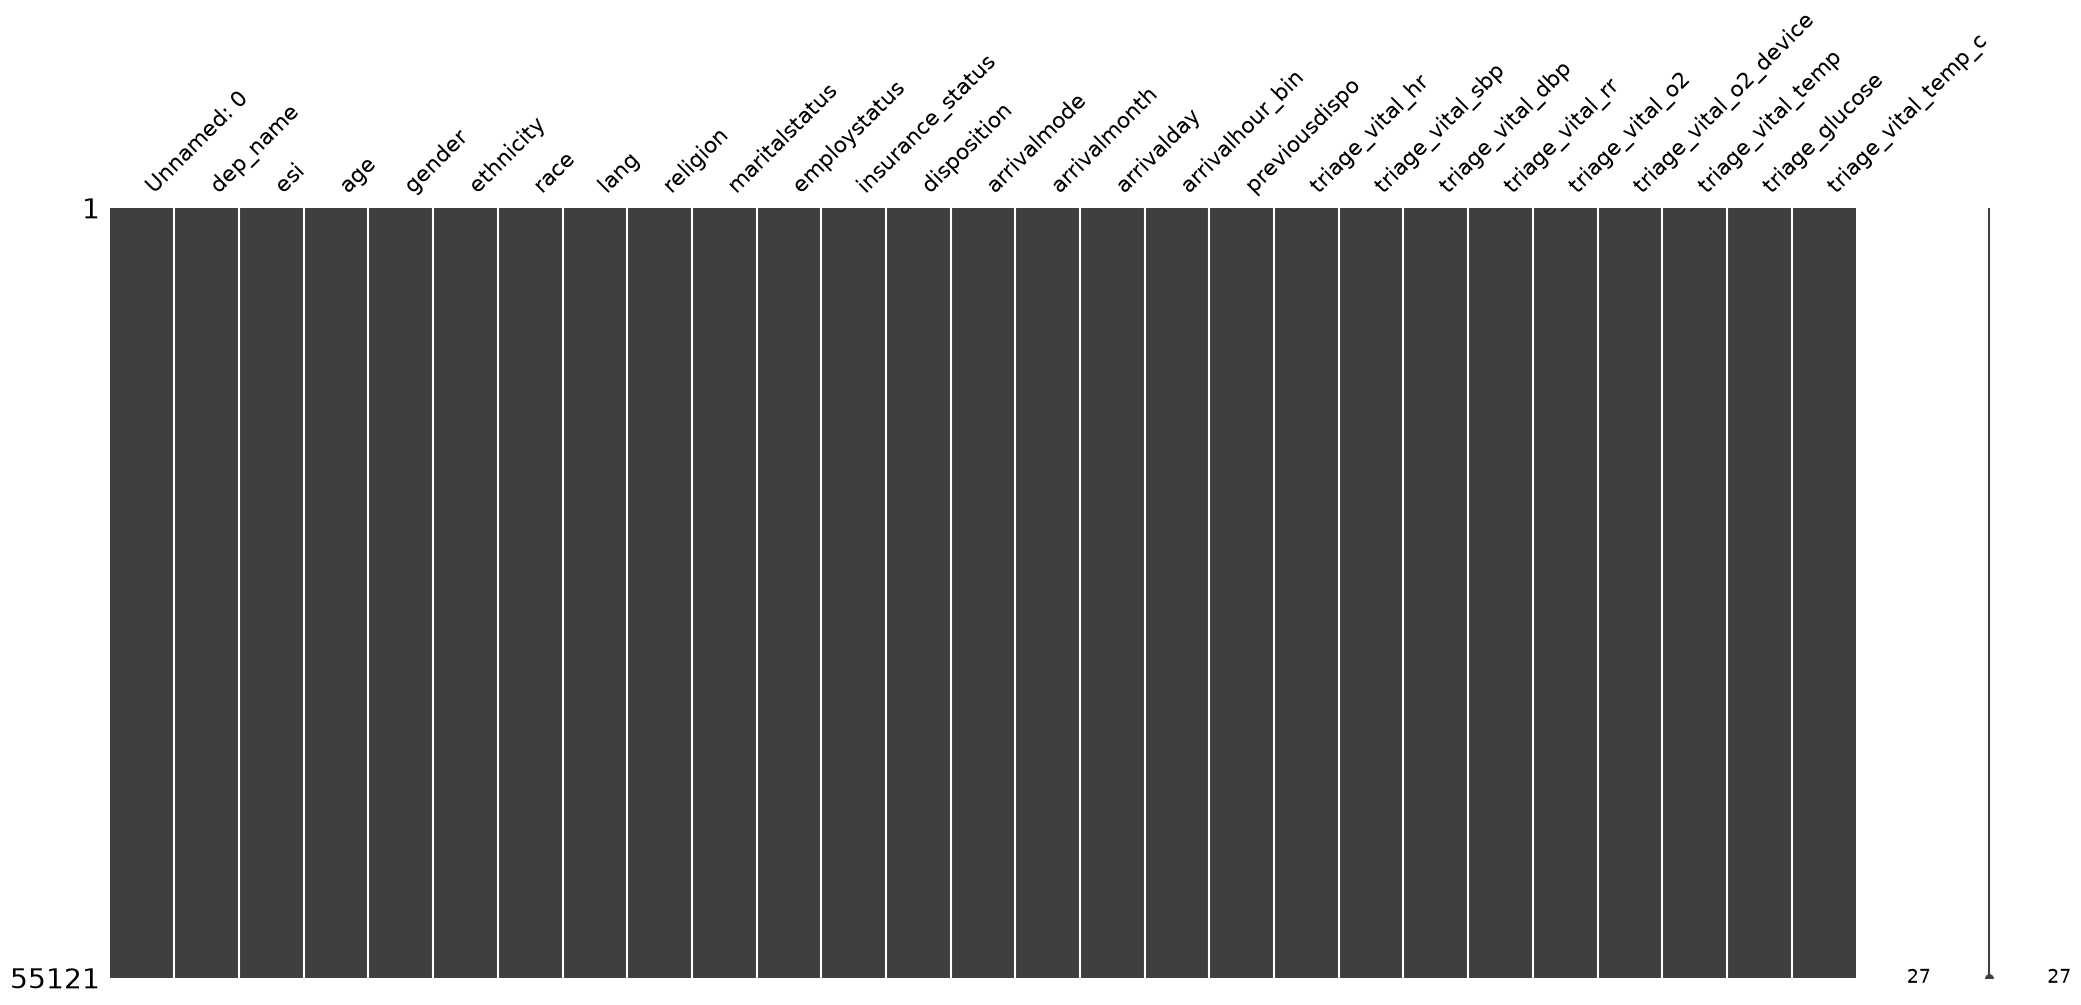

In [7]:
try:
    import missingno as msno              
    msno.matrix(df[structured]); plt.show()
except Exception:
    fig, ax = plt.subplots(figsize=(11,4))
    ax.imshow(df[structured].isna().values, aspect="auto", cmap="gray_r")
    ax.set_xticks(range(len(structured))); ax.set_xticklabels(structured, rotation=90, fontsize=7)
    ax.set_title("Missing cells — structured columns (dark = missing)"); plt.tight_layout(); plt.show()

In [8]:
# the above chart shows data completeness for every structure column across the dataset
# each column is a solid black bar with no white gaps meaning there is no missing data 
# in any of these columns for this dataset.

In [9]:
print(df[structured].dtypes)
print("\n Raw ESI Value Counts:"); print(df[TARGET].value_counts(dropna=False).sort_index())

Unnamed: 0                  int64
dep_name                      str
esi                       float64
age                       float64
gender                        str
ethnicity                     str
race                          str
lang                          str
religion                      str
maritalstatus                 str
employstatus                  str
insurance_status              str
disposition                   str
arrivalmode                   str
arrivalmonth                  str
arrivalday                    str
arrivalhour_bin               str
previousdispo                 str
triage_vital_hr           float64
triage_vital_sbp          float64
triage_vital_dbp          float64
triage_vital_rr           float64
triage_vital_o2           float64
triage_vital_o2_device    float64
triage_vital_temp         float64
triage_glucose            float64
triage_vital_temp_c       float64
dtype: object

 Raw ESI Value Counts:
esi
1.0       77
2.0    17924
3.0    27010
4

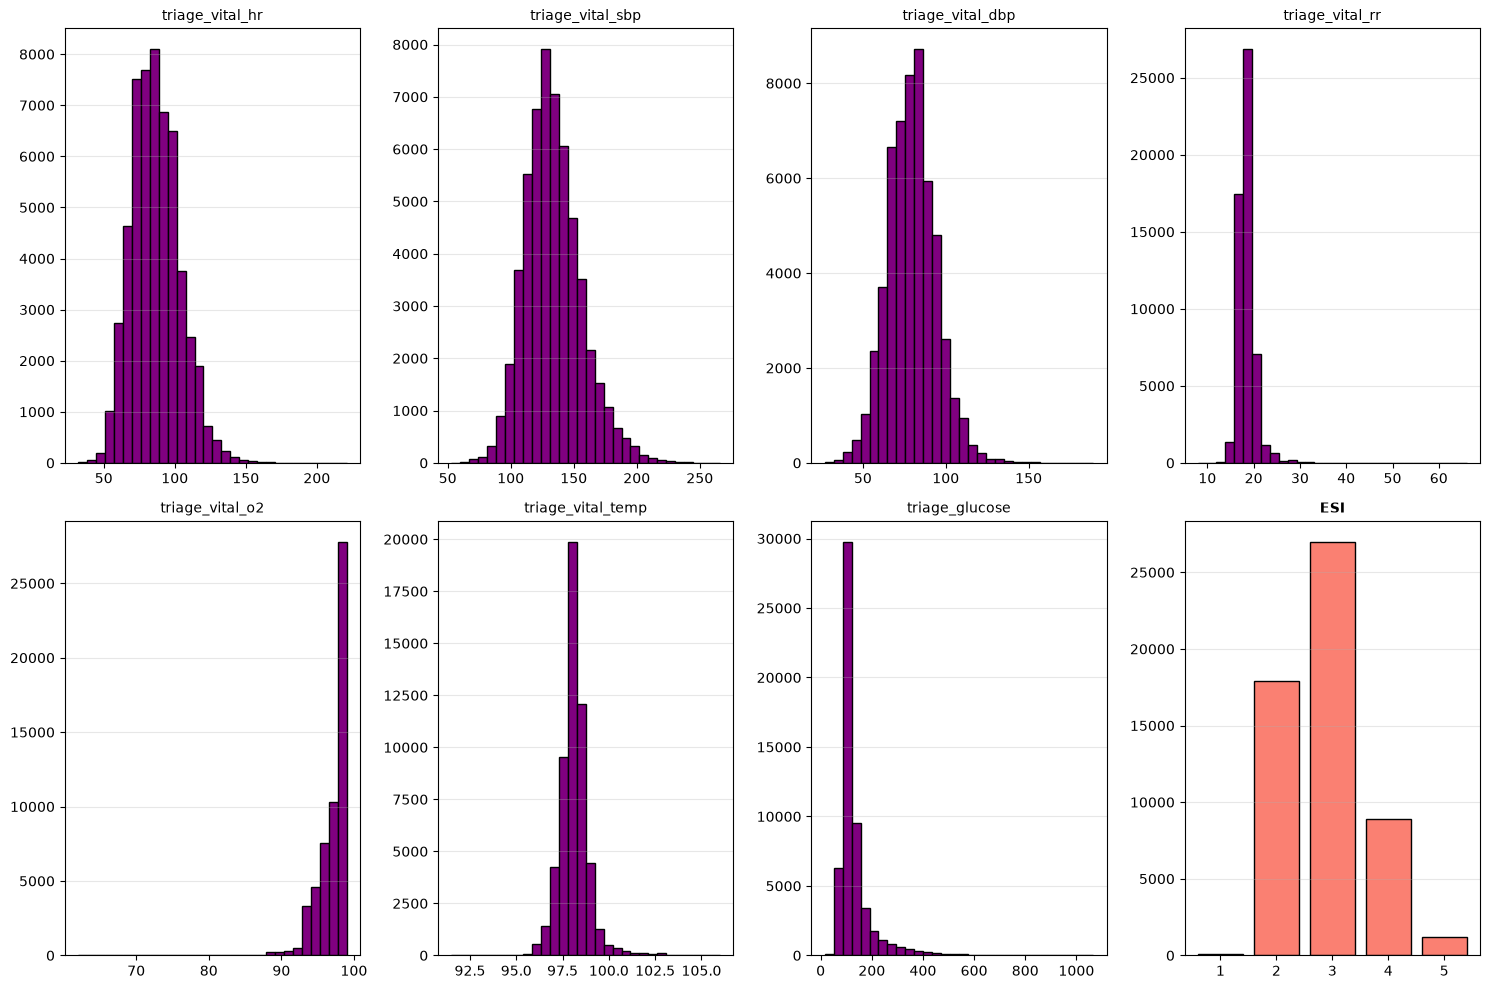

In [10]:
# Drawing a histogram for each vital and the ESI
vitals = fam["vitals"]

# change to a 3x3 grid to fit all 8 vitals and the ESI plot
fig, axes = plt.subplots(2, 4, figsize=(15, 10))
panels = axes.ravel() # flatten the 3x3 grid into a list of 8 panels

# Look through and plot each vital sign
for panel, col in zip(panels, vitals):
    # Convert to numeric, drop missing values and plot
    values = pd.to_numeric(df[col], errors="coerce").dropna()
    panel.hist(values, bins=30, color="purple", edgecolor="black")
    panel.set_title(col, fontsize=10)
    panel.grid(axis="y", alpha=0.3) # adds a grid to make it easily scannable

# Plotting the ESI
esi_counts = df[TARGET].value_counts().sort_index()
panels[-1].bar(esi_counts.index, esi_counts.values, color="salmon", edgecolor="black")
panels[-1].set_title("ESI", fontsize=10, fontweight="bold")
panels[-1].set_xticks(esi_counts.index) # clean integers on the x-axis
panels[-1].grid(axis="y", alpha=0.3)

# Clean the layout to ensure nothing overlaps
plt.tight_layout()
plt.show()

In [11]:
# Demographics - Raw Categories
for c in ["race", "ethnicity", "insurance_status"]:
    print(c, "~>", df[c].value_counts(dropna=False).to_dict())

race ~> {'White or Caucasian': 29435, 'Black or African American': 15963, 'Other': 9016, 'Patient Refused': 370, 'Asian': 175, 'Unknown': 76, 'American Indian or Alaska Native': 66, 'Native Hawaiian or Other Pacific Islander': 20}
ethnicity ~> {'Non-Hispanic': 45142, 'Hispanic or Latino': 9888, 'Patient Refused': 56, 'Unknown': 35}
insurance_status ~> {'Medicaid': 21427, 'Medicare': 17581, 'Commercial': 14056, 'Other': 1883, 'Self pay': 174}


In [12]:
# Outlier Detection:

def outlier_report(df, col):
    """Count two kinds of outlier in one numeric column."""
    x = pd.to_numeric(df[col], errors="coerce").dropna() # numbers only

    # 1. Statistical Outliers
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    low_fence = q1 - 1.5 * iqr
    high_fence = q3 + 1.5 * iqr
    iqr_outliers = ((x < low_fence) | (x > high_fence)).sum()

    # 2. Clinically impossible
    hard_low, hard_high = PLAUSIBLE.get(col, (-np.inf, np.inf))
    impossible = ((x < hard_low) | (x > hard_high)).sum()

    return {"iqr_outliers": iqr_outliers, "impossible": impossible}

# Display outlier summary
report_rows = {}
for col in fam["vitals"]:
    report_rows[col] = outlier_report(df, col)

df_outliers = pd.DataFrame(report_rows).T  # (.T) makes the vital rows and outlier types for the columns
df_outliers

,iqr_outliers,impossible
triage_vital_hr,578,0
triage_vital_sbp,1028,0
triage_vital_dbp,726,0
triage_vital_rr,2366,4
triage_vital_o2,1505,0
triage_vital_temp,3554,0
triage_glucose,5673,25


In [13]:
# Correlation Analysis

# makes a numeric copy of the vitals to correlate with ESI
vitals_numeric = df[fam["vitals"]].copy()
for col in fam["vitals"]:
    vitals_numeric[col] = pd.to_numeric(vitals_numeric[col], errors="coerce")

# 1. Vitals vs ESI
# a negative correlation means the vital value rises as ESI drops (Higher Acuity)
vital_corr = vitals_numeric.corrwith(df[TARGET]).sort_values()
print("Vital vs ESI Correlations:")
print(vital_corr.round(3))

# 2. Chief Complaints vs ESI
# Displaying the top 8 complaints that is associated with lower ESI scores
cc_corr = df[fam["chief_complaints"]].corrwith(df[TARGET]).dropna().sort_values()
print("\nTop 8 Chief Complaints Associated with High Acuity (Low ESI):")
print(cc_corr.head(8).round(3))

Vital vs ESI Correlations:
triage_vital_rr     -0.095
triage_vital_hr     -0.095
triage_glucose      -0.078
triage_vital_temp   -0.022
triage_vital_sbp     0.001
triage_vital_dbp     0.046
triage_vital_o2      0.178
dtype: float64

Top 8 Chief Complaints Associated with High Acuity (Low ESI):
cc_chestpain               -0.164
cc_shortnessofbreath       -0.150
cc_suicidal                -0.143
cc_alcoholintoxication     -0.142
cc_alteredmentalstatus     -0.132
cc_psychiatricevaluation   -0.103
cc_weakness                -0.081
cc_syncope                 -0.075
dtype: float64


/Users/zmcdee/Desktop/CARISURG/notebook-project/venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/zmcdee/Desktop/CARISURG/notebook-project/venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [14]:
# Data Quality 

# Summary of data profiling issues, affected columns, and recommended cleaning steps
issues = [
    {
        "issue": "Missing ESI label", 
        "columns": "esi", 
        "action": "Drop rows where target is missing; cannot train/evaluate supervised models without it."
    },
    {
        "issue": "Missing vitals", 
        "columns": "triage_vital_hr, triage_vital_sbp, triage_vital_dbp, triage_vital_rr, triage_vital_o2", 
        "action": "Impute with median value or flag as missing; drop rows only if entire row is empty."
    },
    {
        "issue": "Clinically impossible values", 
        "columns": "triage_vital_hr, triage_vital_sbp, triage_vital_dbp, triage_vital_rr, triage_vital_o2, triage_glucose", 
        "action": "Clip to PLAUSIBLE bounds or replace extreme values with NaN, then impute."
    },
    {
        "issue": "Fahrenheit temperature scale", 
        "columns": "triage_vital_temp", 
        "action": "Drop raw Fahrenheit column and use the standard Celsius translation (triage_vital_temp_c) for uniformity."
    },
    {
        "issue": "Sparse chief complaints", 
        "columns": "cc_* (e.g., cc_chest_pain, cc_shortness_of_breath)", 
        "action": "Filter out extremely rare codes (occurring in < 0.5% of cases) or group them to prevent feature explosion."
    },
    {
        "issue": "Target leakage", 
        "columns": "disposition, previousdispo", 
        "action": "Strictly drop these columns; they capture information known only AFTER triage and will artificially inflate model scores."
    },
    {
        "issue": "Representativeness/Demographic imbalances", 
        "columns": "race, ethnicity, lang, religion, insurance_status", 
        "action": "Consolidate rare categories into 'Other', stratify train/test splits, and track fairness metrics across groups."
    }
]

# Convert to DataFrame for a clean, scannable summary table
df_audit_report = pd.DataFrame(issues)
df_audit_report

,issue,columns,action
0,Missing ESI label,esi,Drop rows where target is missing; cannot trai...
1,Missing vitals,"triage_vital_hr, triage_vital_sbp, triage_vita...",Impute with median value or flag as missing; d...
2,Clinically impossible values,"triage_vital_hr, triage_vital_sbp, triage_vita...",Clip to PLAUSIBLE bounds or replace extreme va...
3,Fahrenheit temperature scale,triage_vital_temp,Drop raw Fahrenheit column and use the standar...
4,Sparse chief complaints,"cc_* (e.g., cc_chest_pain, cc_shortness_of_bre...",Filter out extremely rare codes (occurring in ...
5,Target leakage,"disposition, previousdispo",Strictly drop these columns; they capture info...
6,Representativeness/Demographic imbalances,"race, ethnicity, lang, religion, insurance_status","Consolidate rare categories into 'Other', stra..."


In [15]:
# 5 · OUTLIERS: IQR = valid clinical variances. Impossible = data-entry anomalies (map to NaN).
# 6 · CORRELATION: ESI is 1-5 (low = acute). Negative correlation = high-acuity predictor.
# 7 · MISSINGNESS: Informative Missingness (MNAR). Severe cases skip triage for immediate care.
# 8 · SPARSITY: Low-variance cc_ flags (<0.5%) cause curse of dimensionality. Drop/aggregate.

# 9 · DATA AUDIT & REMEDIATION PIPELINE
# - Target (esi): Drop rows with missing labels (cannot calculate loss/metrics).
# - Vitals Missingness: Median imputation + append binary missingness indicators.
# - Outlier Vitals: Mask impossible values to NaN, then route to the imputer.
# - Collinearity: Drop Fahrenheit feature; keep Celsius to prevent redundant variance.
# - Feature Reduction: Drop sparse cc_ features to prevent overfitting and noise.
# - Target Leakage: Drop post-triage features (disposition) to avoid lookahead bias.
# - Class Imbalance: Bin sparse categorical tails into 'Other' to ensure parity.